In [3]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, RepeatVector, TimeDistributed, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

In [4]:
# 1. Load the 3D tensors generated in Phase 4
X_train_seq = np.load('X_train_seq.npy')
X_test_seq = np.load('X_test_seq.npy')
y_test_seq = np.load('y_test_seq.npy')

# Extract dimensions
samples, timesteps, features = X_train_seq.shape

print("────────────────────────────────────────────────────────────")
print(f"Loaded Training Data: {samples} samples")
print(f"Sequence Shape:       ({timesteps} timesteps, {features} features)")
print("────────────────────────────────────────────────────────────")

────────────────────────────────────────────────────────────
Loaded Training Data: 7195 samples
Sequence Shape:       (60 timesteps, 9 features)
────────────────────────────────────────────────────────────


In [5]:
def build_gru_autoencoder(timesteps, features):
    model = Sequential(name="Sensor_GRU_Autoencoder")
    
    # Explicit Input Layer
    model.add(Input(shape=(timesteps, features)))
    
    # ─── ENCODER ───
    # Layer 1: Extract initial temporal patterns. 
    # return_sequences=True passes the full 60-timestep sequence to the next layer.
    model.add(GRU(units=32, activation='tanh', return_sequences=True, name="Encoder_GRU_1"))
    
    # Layer 2: The Bottleneck. 
    # return_sequences=False means it only outputs the final state (the compressed representation).
    model.add(GRU(units=8, activation='tanh', return_sequences=False, name="Encoder_Bottleneck"))
    
    # ─── DECODER ───
    # We must expand the 1D bottleneck vector back into a 2D sequence of 60 timesteps
    model.add(RepeatVector(timesteps, name="Decoder_Repeat"))
    
    # Layer 3: Begin reconstruction
    model.add(GRU(units=8, activation='tanh', return_sequences=True, name="Decoder_GRU_1"))
    
    # Layer 4: Match the first layer's capacity
    model.add(GRU(units=32, activation='tanh', return_sequences=True, name="Decoder_GRU_2"))
    
    # Layer 5: TimeDistributed Dense
    # Applies a dense layer independently to every single timestep to map the 32 GRU units 
    # back to the 9 original sensor features.
    model.add(TimeDistributed(Dense(units=features, activation='linear'), name="Reconstruction_Output"))
    
    return model

# Instantiate and compile the model
autoencoder = build_gru_autoencoder(timesteps, features)

# We use Mean Absolute Error (MAE) because it is less sensitive to minor sensor noise 
# than Mean Squared Error (MSE), preventing false positive anomaly spikes.
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mae')

autoencoder.summary()

Model: "Sensor_GRU_Autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Encoder_GRU_1 (GRU)         (None, 60, 32)            4128      
                                                                 
 Encoder_Bottleneck (GRU)    (None, 8)                 1008      
                                                                 
 Decoder_Repeat (RepeatVecto  (None, 60, 8)            0         
 r)                                                              
                                                                 
 Decoder_GRU_1 (GRU)         (None, 60, 8)             432       
                                                                 
 Decoder_GRU_2 (GRU)         (None, 60, 32)            4032      
                                                                 
 Reconstruction_Output (Time  (None, 60, 9)            297       
 Distributed)                               


Starting Training...
Epoch 1/50
48/48 [==============================] - ETA: 0s - loss: 0.2493
Epoch 1: val_loss improved from inf to 0.13658, saving model to best_gru_autoencoder.keras
48/48 [==============================] - 16s 172ms/step - loss: 0.2493 - val_loss: 0.1366
Epoch 2/50
48/48 [==============================] - ETA: 0s - loss: 0.1348
Epoch 2: val_loss did not improve from 0.13658
48/48 [==============================] - 7s 136ms/step - loss: 0.1348 - val_loss: 0.1398
Epoch 3/50
48/48 [==============================] - ETA: 0s - loss: 0.1196
Epoch 3: val_loss improved from 0.13658 to 0.12309, saving model to best_gru_autoencoder.keras
48/48 [==============================] - 7s 137ms/step - loss: 0.1196 - val_loss: 0.1231
Epoch 4/50
48/48 [==============================] - ETA: 0s - loss: 0.1049
Epoch 4: val_loss improved from 0.12309 to 0.11345, saving model to best_gru_autoencoder.keras
48/48 [==============================] - 7s 144ms/step - loss: 0.1049 - val_loss: 

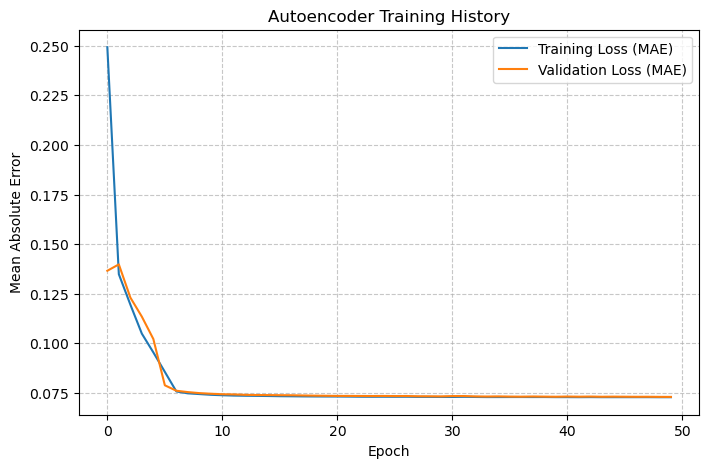

In [6]:
# ─── Callbacks ───
# Stop training if validation loss doesn't improve for 5 epochs
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

# Save the best version of the model automatically
checkpoint = ModelCheckpoint(
    'best_gru_autoencoder.keras', 
    monitor='val_loss', 
    save_best_only=True,
    verbose=1
)

print("\nStarting Training...")
# Train the model. Input is X_train_seq, Target is ALSO X_train_seq.
history = autoencoder.fit(
    X_train_seq, X_train_seq,  
    epochs=50,
    batch_size=128, # Larger batch size speeds up training and smooths gradients
    validation_split=0.15, # Use 15% of train data to monitor overfitting
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

# Plot the training history to verify convergence
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss (MAE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MAE)')
plt.title('Autoencoder Training History')
plt.ylabel('Mean Absolute Error')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Reconstructing training data to establish baseline error...
57/57 [==============================] - 3s 35ms/step
────────────────────────────────────────────────────────────
Baseline MAE Mean:  0.07284
Baseline MAE StDev: 0.00326
Calculated Anomaly Threshold (Tau): 0.08261
────────────────────────────────────────────────────────────


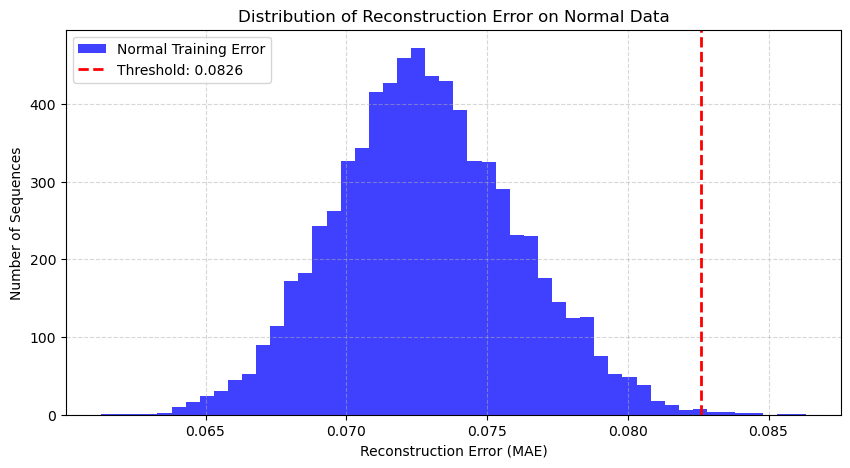

In [8]:
# 1. Ask the model to reconstruct the normal training data
print("Reconstructing training data to establish baseline error...")
X_train_pred = autoencoder.predict(X_train_seq, batch_size=128)

# 2. Calculate the Mean Absolute Error for every single sequence
# We average the error across all timesteps and features for each window
train_mae_loss = np.mean(np.abs(X_train_pred - X_train_seq), axis=(1, 2))

# 3. Calculate mean and standard deviation of the error
error_mean = np.mean(train_mae_loss)
error_std = np.std(train_mae_loss)

# 4. Set the Threshold (3 standard deviations above the mean covers 99.7% of normal data)
# You can tweak this multiplier later (e.g., 4 or 5) if you get too many false positives.
THRESHOLD = error_mean + (3 * error_std)

print("────────────────────────────────────────────────────────────")
print(f"Baseline MAE Mean:  {error_mean:.5f}")
print(f"Baseline MAE StDev: {error_std:.5f}")
print(f"Calculated Anomaly Threshold (Tau): {THRESHOLD:.5f}")
print("────────────────────────────────────────────────────────────")

# Plot the distribution of reconstruction errors
plt.figure(figsize=(10, 5))
plt.hist(train_mae_loss, bins=50, alpha=0.75, color='blue', label='Normal Training Error')
plt.axvline(THRESHOLD, color='red', linestyle='dashed', linewidth=2, label=f'Threshold: {THRESHOLD:.4f}')
plt.title('Distribution of Reconstruction Error on Normal Data')
plt.xlabel('Reconstruction Error (MAE)')
plt.ylabel('Number of Sequences')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [9]:
import json

# Save the threshold to a JSON file for deployment
config = {
    "threshold_mae": float(THRESHOLD),
    "window_size": timesteps,
    "features": features
}

with open('model_config.json', 'w') as f:
    json.dump(config, f)

print("Saved model configuration and threshold to model_config.json")
print("Phase 5 Complete. Next: Phase 6 — Evaluating against the test set anomalies.")

Saved model configuration and threshold to model_config.json
Phase 5 Complete. Next: Phase 6 — Evaluating against the test set anomalies.
